# Stylometry
Find differences between academic and news texts in BNC using a couple metrics

In [74]:
import polars as pl
import polars_corpus as plc
import polars.selectors as cs
import matplotlib.pyplot as plt
import seaborn as sns

pl.Config.set_float_precision(3)
pl.Config.set_tbl_rows(15)

polars.config.Config

In [81]:
brown = pl.scan_parquet("../data/brown.parquet") \
    .filter(           plc.is_letters("token")) \
    .with_columns(pl.col('token').str.to_lowercase()) \
    .collect()

In [129]:
msttr = brown.group_by('file_id').agg(pl.col('category').first(),
                                plc.ttr("token").alias('ttr'),
                                      plc.ttr(pl.col("token").head(500)).alias('ttr500'),
                                      plc.msttr("token",500).alias('msttr'),
                                          plc.mtld("token").alias("mtld"))
msttr.group_by('category').agg(cs.numeric().mean())


category,ttr,ttr500,msttr,mtld
str,f64,f64,f64,f64
"""government""",0.311,0.454,0.455,66.086
"""religion""",0.352,0.485,0.496,79.682
"""mystery""",0.354,0.519,0.515,98.598
"""romance""",0.358,0.523,0.518,101.082
"""fiction""",0.377,0.527,0.526,97.180
"""adventure""",0.370,0.533,0.527,104.932
"""hobbies""",0.361,0.519,0.509,90.691
"""learned""",0.323,0.476,0.472,73.701
"""humor""",0.418,0.559,0.555,117.023


<Axes: xlabel='mtld', ylabel='category'>

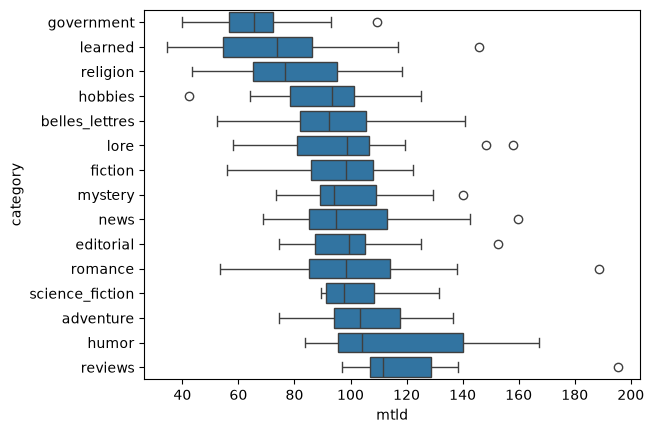

In [131]:
z = msttr.with_columns(m=pl.col('mtld').mean().over('category')).sort(by='m')


sns.boxplot(z, x="mtld", y="category")

<Axes: xlabel='msttr', ylabel='mtld'>

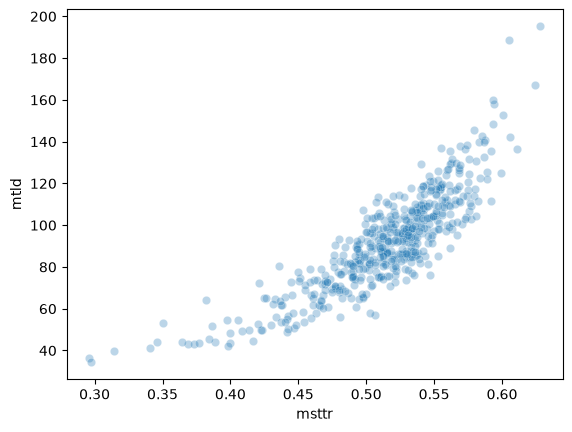

In [141]:
sns.scatterplot(z, x="msttr", y="mtld", alpha=0.3)

In [122]:
subset = ['austen-emma.txt',
 'chesterton-ball.txt',
 'edgeworth-parents.txt',
 'burgess-busterbrown.txt',
 'melville-moby_dick.txt',
 'bryant-stories.txt']

books = pl.scan_parquet("../data/books.parquet") \
    .filter(pl.col('file_id').is_in(subset),
           plc.is_letters("token")) \
    .with_columns(pl.col('token').str.to_lowercase()) \
    .collect()

In [145]:
mtld = books.group_by('file_id').agg(plc.mtld("token").alias('mtld'))
mtld


file_id,mtld
str,f64
"""burgess-busterbrown.txt""",67.390
"""edgeworth-parents.txt""",77.037
"""bryant-stories.txt""",55.816
"""melville-moby_dick.txt""",105.638
"""austen-emma.txt""",91.232
"""chesterton-ball.txt""",79.959


<Axes: xlabel='mtld', ylabel='file_id'>

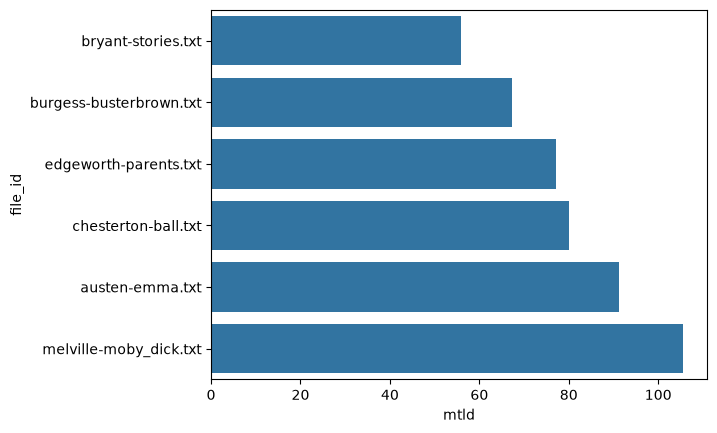

In [148]:
sns.barplot(mtld.sort(by="mtld"), y="file_id", x="mtld")

In [149]:
vgc = books.filter(pl.col('file_id')=='austen-emma.txt') \
    .with_columns(plc.vocabulary_growth('token').alias('types')) \
    .with_row_index()


<Axes: xlabel='index', ylabel='types'>

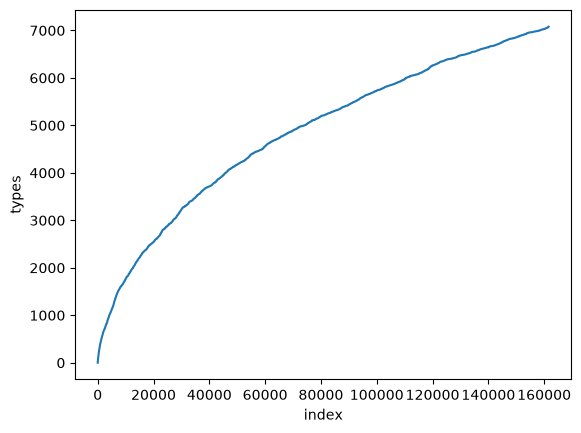

In [150]:
sns.lineplot(vgc, x="index", y="types")

In [151]:
vgc = books \
    .with_columns(plc.vocabulary_growth('token').alias('types').over('file_id'),
                  pl.row_index().over("file_id").alias("index"))


<Axes: xlabel='index', ylabel='types'>

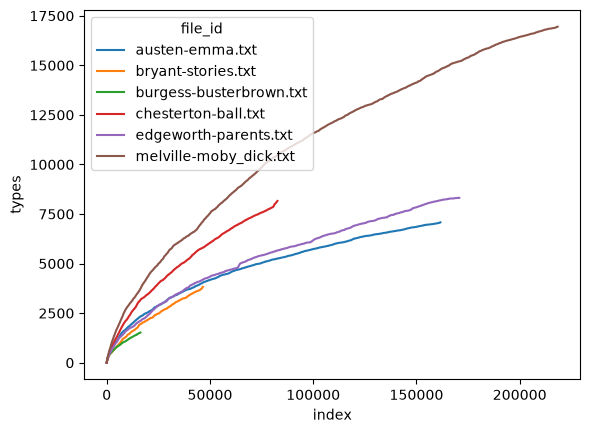

In [152]:
sns.lineplot(vgc, x="index", y="types", hue='file_id')